
# Text Classification on AG News
### Models: FastText, Naive Bayes

This notebook includes:
- Data loading
- Exploratory Data Analysis (EDA)
- Preprocessing
- Classical baseline (Naive Bayes)
- FastText model
- Evaluation (accuracy, confusion matrix)
- Speed comparison
- Visualizations


In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# HuggingFace datasets
from datasets import load_dataset

# Transformers
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
import torch

# FastText (requires pip install fasttext)


In [4]:

dataset = load_dataset("ag_news")

train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

train_df.head()


,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


label
2    30000
3    30000
1    30000
0    30000
Name: count, dtype: int64


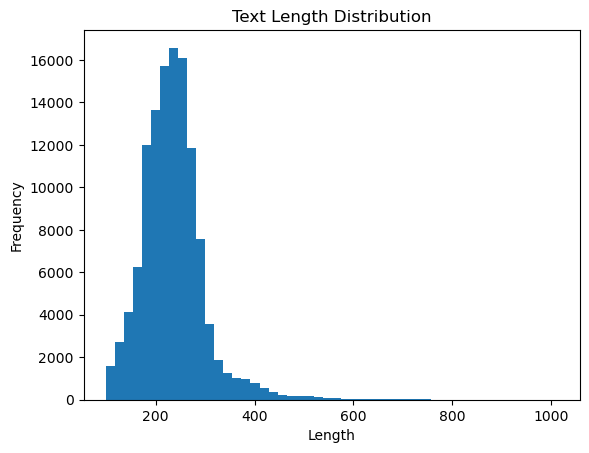

In [5]:

print(train_df['label'].value_counts())

train_df['text_length'] = train_df['text'].apply(len)

plt.hist(train_df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()


In [6]:

X_train = train_df['text']
y_train = train_df['label']

X_test = test_df['text']
y_test = test_df['label']


## Naive Bayes

In [7]:

start = time.time()

vectorizer = TfidfVectorizer(max_features=20000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_preds = nb_model.predict(X_test_tfidf)

nb_time = time.time() - start
nb_acc = accuracy_score(y_test, nb_preds)

print("Naive Bayes Accuracy:", nb_acc)
print("Time:", nb_time)


Naive Bayes Accuracy: 0.8992105263157895
Time: 2.7716119289398193


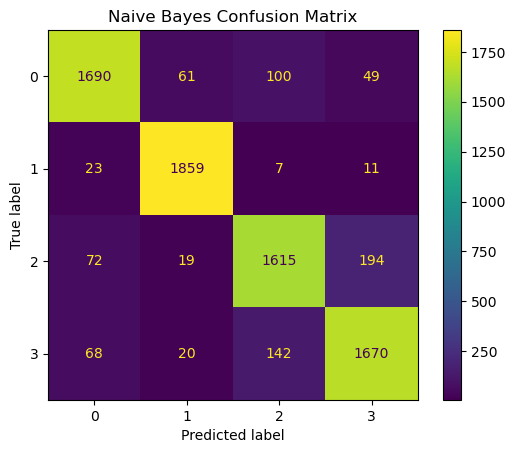

In [8]:

cm = confusion_matrix(y_test, nb_preds)
ConfusionMatrixDisplay(cm).plot()
plt.title("Naive Bayes Confusion Matrix")
plt.show()


## FastText

In [9]:
import fasttext
import time
from sklearn.metrics import accuracy_score

# ---------------------------
# 1. PREPARE TRAIN FILE (CORRECT FORMAT)
# ---------------------------
train_df_ft = train_df.copy()
train_df_ft['label'] = "__label__" + train_df_ft['label'].astype(str)

with open("train_ft.txt", "w") as f:
    for _, row in train_df_ft.iterrows():
        text = str(row['text']).replace("\n", " ")
        f.write(f"{row['label']} {text}\n")

# ---------------------------
# 2. TRAIN FASTTEXT
# ---------------------------
start = time.time()

ft_model = fasttext.train_supervised(
    input="train_ft.txt",
    epoch=5,
    lr=0.5,
    wordNgrams=2
)

ft_time = time.time() - start

# ---------------------------
# 3. PREDICT (WORKS AFTER NUMPY FIX)
# ---------------------------
preds = []

for text in X_test:
    labels, probs = ft_model.predict(str(text))
    preds.append(int(labels[0].replace("__label__", "")))

# ---------------------------
# 4. EVALUATE
# ---------------------------
ft_acc = accuracy_score(y_test, preds)

print("FastText Accuracy:", ft_acc)
print("Training Time:", ft_time)

Read 4M words
Number of words:  188111
Number of labels: 4
Progress: 100.0% words/sec/thread: 1803582 lr:  0.000000 avg.loss:  0.124636 ETA:   0h 0m 0s


FastText Accuracy: 0.9172368421052631
Training Time: 2.601623773574829


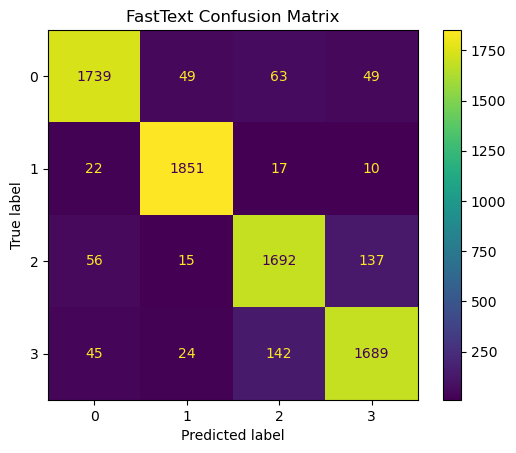

In [10]:

cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm).plot()
plt.title("FastText Confusion Matrix")
plt.show()


## Model Comparison

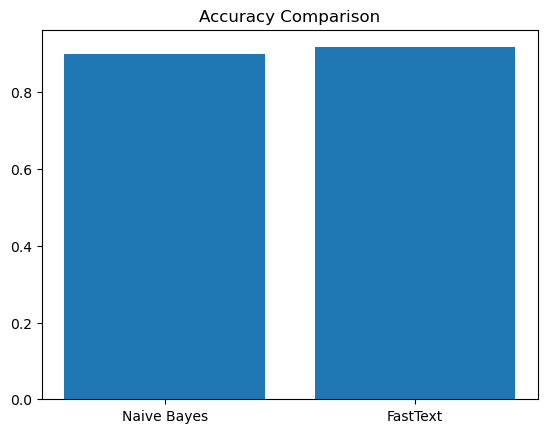

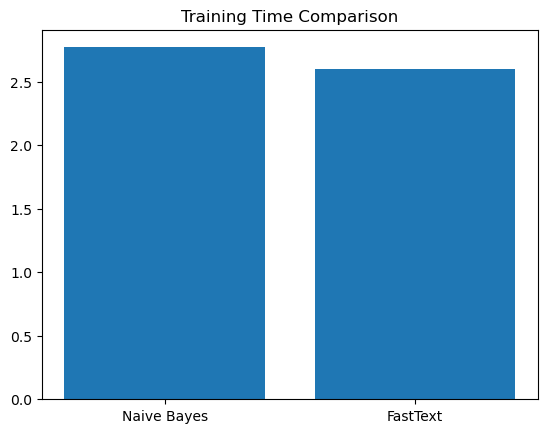

In [20]:

models = ["Naive Bayes", "FastText"]
accuracies = [nb_acc, ft_acc]
times = [nb_time, ft_time]

plt.figure()
plt.bar(models, accuracies)
plt.title("Accuracy Comparison")
plt.show()

plt.figure()
plt.bar(models, times)
plt.title("Training Time Comparison")
plt.show()
